# 0. Imports and inputs

In [1]:
# import the library
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import calendar
import numpy as np
import matplotlib.dates as mdates
import sys
import os
from os import listdir
from os.path import isfile, join
from dateutil import parser
import re
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (GradientBoostingRegressor, 
                              RandomForestRegressor, 
                              AdaBoostRegressor, 
                              BaggingRegressor, 
                              ExtraTreesRegressor,
                              HistGradientBoostingRegressor,
                              StackingRegressor,
                              VotingRegressor)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from datetime import datetime, timedelta
from matplotlib import animation
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
# from func_defs import *

# %matplotlib ipympl
%matplotlib inline


# define the inverter to analyse
inverter = '2-1'

# define the plot template
axis_label_size = 15
axis_num_size = 12
text_size = 12
title_size = 22

# define the figure size for single plot
figure_size = (6, 6)
subplot_size_1_2 = (6, 6)
long_hoz_figsize = (12, 6)

# define the file directory for SunSolve data
sunsolve_dir = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\SunSolve Yield\Per inverter\2-1\0_mimic_PVsyst\25_09_18_Bomen_2021_1.csv"
# define the file directory for PVsyst data
pvsyst_dir = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\PVsyst\per_inv\2-1\Bomen solar farm 2021 19 0.0 Perez model.csv"

# 1. Data loading 

## 1.1. SunSolve Yield data loading

In [2]:
# Load the SunSolve yield data as csv file
sunsolve_df = pd.read_csv(sunsolve_dir)

# Print the columns of the SunSolve df
# print("Columns in SunSolve data:")
print(sunsolve_df.columns)

# Create a timestamp column from the Day of year, Hour, and Minute columns
# First, we need to determine the year (assuming 2021 from your file naming)
year = 2021

# Create a timestamp using a different approach - convert day of year to date
# This creates a base date for the year and adds the day of year as timedelta
base_date = pd.Timestamp(f"{year}-01-01")  # January 1st of the specified year
sunsolve_df['Timestamp'] = sunsolve_df.apply(
    lambda row: base_date + pd.Timedelta(days=int(row['Day of year'])-1) + 
                pd.Timedelta(hours=int(row['Hour'])) + 
                pd.Timedelta(minutes=int(row['Minute'])),
    axis=1
)

# print("Created timestamp column.")
# print(sunsolve_df['Timestamp'].head())

# Define a scaling factor for the SunSolve df power
sunsolve_scaling_1 = 1e-3

# Convert power from W to MW
sunsolve_df['Inverter power (MW)'] = sunsolve_df['Power [unit-system] (W)'] * sunsolve_scaling_1

# Set the timestamp as the index for easier resampling
sunsolve_df.set_index('Timestamp', inplace=True)

# Now resample to hourly data using the index
# For hourly data converted to hourly energy, we need to multiply by the time period
# The 'Period (h)' column contains the duration of each data point in hours
sunsolve_df['Hourly energy (MWh)'] = sunsolve_df['Inverter power (MW)'] * sunsolve_df['Period (h)']

# Identify all columns containing "(W)" - these are power measurements
power_columns = [col for col in sunsolve_df.columns if "(W)" in col]

# Create energy columns for each power column
for col in power_columns:
    # Create a new column name by replacing "(W)" with "(Wh)"
    energy_col_name = col.replace("(W)", "(Wh)")
    
    # Convert power to energy by multiplying by the time period
    sunsolve_df[energy_col_name] = sunsolve_df[col] * sunsolve_df['Period (h)']

# Resample all energy columns to hourly totals
hourly_energy_df = sunsolve_df[[col for col in sunsolve_df.columns if "(Wh)" in col]].resample('H').sum()

# Convert from Wh to MWh for consistency with your other calculations
for col in hourly_energy_df.columns:
    hourly_energy_df[col] = hourly_energy_df[col] * 1e-6  # Convert Wh to MWh
    new_col_name = col.replace("(Wh)", "(MWh/hour)")
    hourly_energy_df.rename(columns={col: new_col_name}, inplace=True)

# Display the results
print("hourly energy values from power measurements:")
print(hourly_energy_df.head())

# Initialize sunsolve_hourly with the hourly energy resampled to hourly
sunsolve_hourly = sunsolve_df['Hourly energy (MWh)'].resample('H').sum().to_frame(name='Inverter energy (MWh/hour)')

# Merge with the other energy columns
sunsolve_hourly = pd.concat([sunsolve_hourly, hourly_energy_df], axis=1)

# print hte columns of hte sunsolve_hourly
print("Columns in hourly resampled SunSolve data:")
print(sunsolve_hourly.columns)

Index(['Day of year', 'Hour', 'Minute', 'Period (h)', 'Flag', 'Message',
       'Solar zenith (degrees)', 'Solar elevation (degrees)',
       'Solar azimuth (degrees)', 'GHI (W/m2)', 'DHI (W/m2)', 'DNI (W/m2)',
       'Diffuse fraction', 'Ambient temperature (°C)', 'Wind velocity (m/s)',
       'Wind direction', 'Opaque cloud fraction', 'Air mass',
       'Precipitable water vapour (cm)', 'Ozone (atm.cm)',
       'Aerosol optical density', 'Relative humidity (%)',
       'Far field albedo (%)', 'Surface pressure (mb)',
       'Module tilt (degrees)', 'Incident angle (degrees)',
       'VF power for Tmod [average] (W/m2)',
       'VF power for Tmod front [average] (W/m2)',
       'VF power for Tmod rear [average] (W/m2)',
       'Module temperature [average] (C)',
       'Power - no mismatch @25C [unit-system] (W)',
       'Power - no mismatch [unit-system] (W)', 'Power [unit-system] (W)',
       'Vmp [average] (V)', 'Imp [average] (A)', 'Imp [minimum] (A)',
       'Voc [average] (V)', 

C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\2169997403.py:51: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_energy_df = sunsolve_df[[col for col in sunsolve_df.columns if "(Wh)" in col]].resample('H').sum()
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\2169997403.py:64: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = sunsolve_df['Hourly energy (MWh)'].resample('H').sum().to_frame(name='Inverter energy (MWh/hour)')


## 1.2. PVsyst data loading

In [3]:
# read the csv file
PVsyst_results_df = pd.read_csv(
    pvsyst_dir,
    delimiter=';',
    skiprows=list(range(10)) + [11],  # Skip metadata (0-9) and units row (11)
    header=0,  # Row 10 becomes the header after skipping
    encoding='latin-1',  # Keep the encoding that worked
    low_memory=False,
    na_values=['', ' ', 'nan', 'NaN']
)

# Convert to datetime using the correct format with 2-digit year (%y instead of %Y)
PVsyst_results_df['date'] = pd.to_datetime(PVsyst_results_df['date'], format='%d/%m/%y %H:%M')


# Set the timestamp as the index for easier plotting
PVsyst_results_df.set_index('date', inplace=True)

# resample to hourly energy by summing up the hourly energy values
PVsyst_hourly = PVsyst_results_df['EArray'].resample('H').sum().to_frame(name='PVsyst energy (MWh/hour)')

C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\957420745.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  PVsyst_hourly = PVsyst_results_df['EArray'].resample('H').sum().to_frame(name='PVsyst energy (MWh/hour)')


# 2. Data comparison

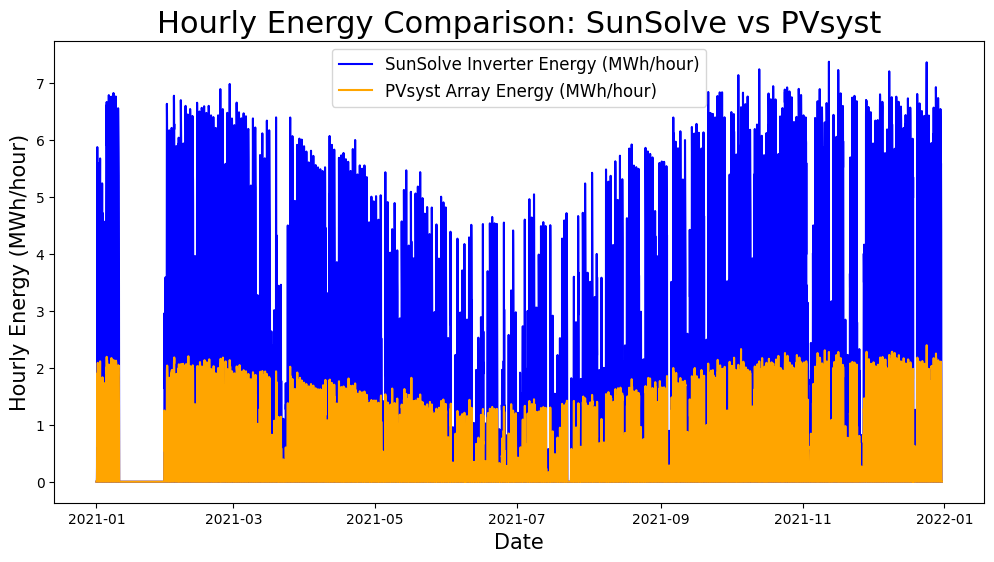

CRMSE: 1.6257 MWh/hour
RMSE: 1.6257 MWh/hour
MBE: 0.8708 MWh/hour
NRMSE: 0.6787


In [4]:
# plot the hourly energy from both datasets for comparison
plt.figure(figsize=long_hoz_figsize)
plt.plot(sunsolve_hourly.index, sunsolve_hourly['Inverter energy (MWh/hour)'], label='SunSolve Inverter Energy (MWh/hour)', color='blue')
plt.plot(PVsyst_hourly.index, PVsyst_hourly['PVsyst energy (MWh/hour)'], label='PVsyst Array Energy (MWh/hour)', color='orange')
plt.xlabel('Date', fontsize=axis_label_size)
plt.ylabel('Hourly Energy (MWh/hour)', fontsize=axis_label_size)
plt.title('Hourly Energy Comparison: SunSolve vs PVsyst', fontsize=title_size)
plt.legend(fontsize=text_size)
plt.show()

# calculate hte evaluation matrix: CRMSE, RMSE, MBE, NRMSE, then print
merged_hourly = pd.merge(sunsolve_hourly, PVsyst_hourly, left_index=True, right_index=True, how='inner')
merged_hourly.dropna(inplace=True)  # Drop rows with NaN values
crmse = np.sqrt(mean_squared_error(merged_hourly['PVsyst energy (MWh/hour)'], merged_hourly['Inverter energy (MWh/hour)']))
rmse = np.sqrt(mean_squared_error(merged_hourly['PVsyst energy (MWh/hour)'], merged_hourly['Inverter energy (MWh/hour)']))
mbe = np.mean(merged_hourly['Inverter energy (MWh/hour)'] - merged_hourly['PVsyst energy (MWh/hour)'])
nrmse = rmse / (merged_hourly['PVsyst energy (MWh/hour)'].max() - merged_hourly['PVsyst energy (MWh/hour)'].min())
print(f"CRMSE: {crmse:.4f} MWh/hour")
print(f"RMSE: {rmse:.4f} MWh/hour")
print(f"MBE: {mbe:.4f} MWh/hour")
print(f"NRMSE: {nrmse:.4f}")


# 3. Optimisation

=== OPTIMIZING SUNSOLVE SCALING FACTOR ===
Target MBE tolerance: 1e-13 MWh/hour
         Press Ctrl+C to interrupt if the search takes too long.

Optimising scale for 2021-01-31 → 2021-02-01
Initial search range: [0.0010000000, 0.1000000000]
Initial MBE: -8.6557754800e-01
Iteration 1: Factor = 0.0505000000, MBE = -8.6545617404e-01
Iteration 2: Factor = 0.0752500000, MBE = -8.6539548706e-01
Iteration 3: Factor = 0.0876250000, MBE = -8.6536514357e-01
Iteration 4: Factor = 0.0938125000, MBE = -8.6534997183e-01
Iteration 5: Factor = 0.0969062500, MBE = -8.6534238596e-01
Iteration 6: Factor = 0.0984531250, MBE = -8.6533859302e-01
Iteration 7: Factor = 0.0992265625, MBE = -8.6533669655e-01
Iteration 8: Factor = 0.0996132813, MBE = -8.6533574832e-01
Iteration 9: Factor = 0.0998066406, MBE = -8.6533527420e-01
Iteration 10: Factor = 0.0999033203, MBE = -8.6533503714e-01
Iteration 20: Factor = 0.0999999056, MBE = -8.6533480031e-01
Iteration 30: Factor = 0.0999999999, MBE = -8.6533480008e-01
Iter

C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scal

Iteration 100: Factor = 0.1000000000, MBE = -8.6533480008e-01
Expanding search range downward: 0.1000000000 -> 0.0100000000
Expanding search range upward: 0.1000000000 -> 1.0000000000
Iteration 110: Factor = 0.9990332031, MBE = -8.6313037142e-01
Iteration 120: Factor = 0.9999990559, MBE = -8.6312800315e-01
Iteration 130: Factor = 0.9999999991, MBE = -8.6312800084e-01
Iteration 140: Factor = 1.0000000000, MBE = -8.6312800083e-01
Iteration 150: Factor = 1.0000000000, MBE = -8.6312800083e-01
Iteration 160: Factor = 1.0000000000, MBE = -8.6312800083e-01
Iteration 170: Factor = 1.0000000000, MBE = -8.6312800083e-01


C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scal

Iteration 180: Factor = 1.0000000000, MBE = -8.6312800083e-01
Iteration 190: Factor = 1.0000000000, MBE = -8.6312800083e-01
Iteration 200: Factor = 1.0000000000, MBE = -8.6312800083e-01
Expanding search range downward: 1.0000000000 -> 0.1000000000
Expanding search range upward: 1.0000000000 -> 10.0000000000
Iteration 210: Factor = 9.9903320313, MBE = -8.4108371420e-01
Iteration 220: Factor = 9.9999905586, MBE = -8.4106003150e-01
Iteration 230: Factor = 9.9999999908, MBE = -8.4106000837e-01
Iteration 240: Factor = 10.0000000000, MBE = -8.4106000835e-01
Iteration 250: Factor = 10.0000000000, MBE = -8.4106000835e-01
Iteration 260: Factor = 10.0000000000, MBE = -8.4106000835e-01


...

Iteration 270: Factor = 10.0000000000, MBE = -8.4106000835e-01
Iteration 280: Factor = 10.0000000000, MBE = -8.4106000835e-01


C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scal

Iteration 290: Factor = 10.0000000000, MBE = -8.4106000835e-01
Iteration 300: Factor = 10.0000000000, MBE = -8.4106000835e-01
Expanding search range downward: 10.0000000000 -> 1.0000000000
Expanding search range upward: 10.0000000000 -> 100.0000000000
Iteration 310: Factor = 99.9033203125, MBE = -6.2061714201e-01
Iteration 320: Factor = 99.9999055862, MBE = -6.2038031500e-01
Iteration 330: Factor = 99.9999999078, MBE = -6.2038008372e-01
Iteration 340: Factor = 99.9999999999, MBE = -6.2038008349e-01
Iteration 350: Factor = 100.0000000000, MBE = -6.2038008349e-01
Iteration 360: Factor = 100.0000000000, MBE = -6.2038008349e-01
Iteration 370: Factor = 100.0000000000, MBE = -6.2038008349e-01
Iteration 380: Factor = 100.0000000000, MBE = -6.2038008349e-01


C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
C:\Users\z5183876\AppData\Local\Temp\ipykernel_30936\4235510103.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sunsolve_hourly = scal

Iteration 390: Factor = 100.0000000000, MBE = -6.2038008349e-01
Iteration 400: Factor = 100.0000000000, MBE = -6.2038008349e-01
Expanding search range downward: 100.0000000000 -> 10.0000000000
Expanding search range upward: 100.0000000000 -> 1000.0000000000
Iteration 410: Factor = 353.2128906250, MBE = 4.9771289952e-04
Iteration 420: Factor = 353.0099010468, MBE = -1.7376860635e-08
Iteration 430: Factor = 353.0099075008, MBE = -1.5514975882e-09
Iteration 440: Factor = 353.0099081338, MBE = 5.7138738185e-13
✓ Converged! Found factor with MBE below tolerance.

=== OPTIMIZATION RESULTS ===
Date window: 2021-01-31 → 2021-02-01
Original scaling factor: 0.0010000000
Optimal scaling factor (filtered): 353.0099081336
Final MBE: 1.941113936255e-14 MWh/hour
Found in 442 iterations

=== APPLYING OPTIMAL SCALING FACTOR (FILTERED WINDOW) ===

=== METRICS WITH OPTIMAL SCALING (FILTERED) ===
RMSE: 0.1392 MWh/hour
MBE: 1.9411e-14 MWh/hour
NRMSE: 0.0683


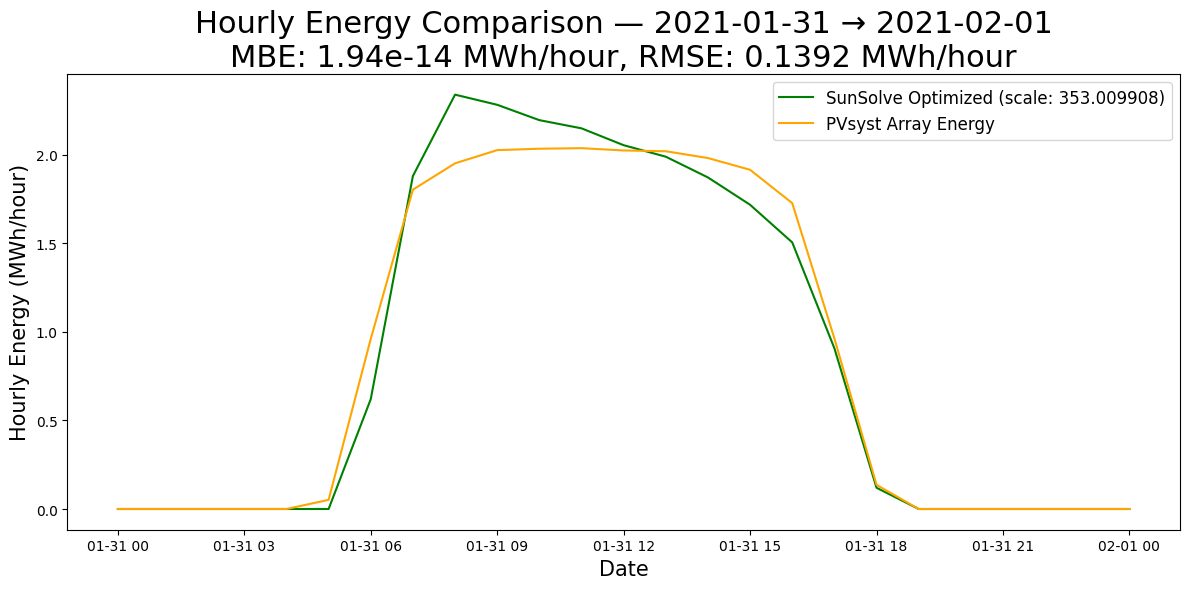

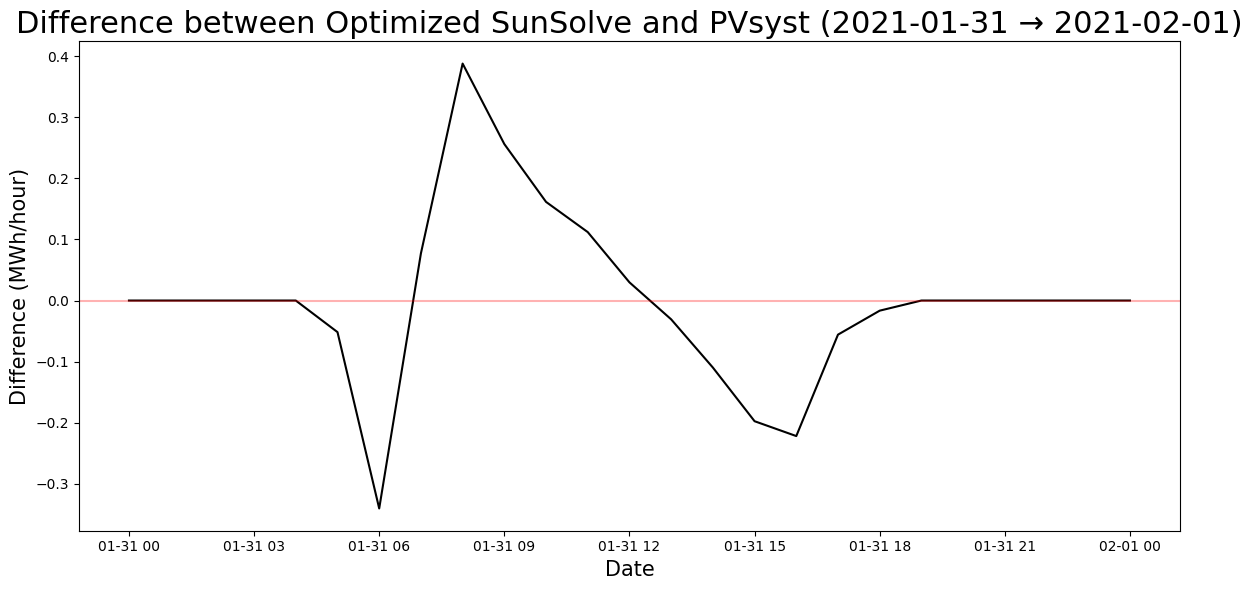

In [5]:
print("=== OPTIMIZING SUNSOLVE SCALING FACTOR ===")
print("Target MBE tolerance: 1e-13 MWh/hour")
print("WARNING: Running with unlimited iterations and no factor boundaries.")
print("         Press Ctrl+C to interrupt if the search takes too long.")

DATE_RANGE = ("2021-01-31", "2021-02-01")  # set to None for full series
# DATE_RANGE = None

if DATE_RANGE is not None:
    start_date, end_date = map(pd.Timestamp, DATE_RANGE)
    sunsolve_filtered = sunsolve_df.loc[start_date:end_date]
    pvsyst_filtered = PVsyst_hourly.loc[start_date:end_date]
    window_label = f"{start_date.date()} → {end_date.date()}"
else:
    sunsolve_filtered = sunsolve_df
    pvsyst_filtered = PVsyst_hourly
    window_label = "full period"

def calculate_mbe(scale_factor):
    """Mean Bias Error restricted to the filtered date window."""
    scaled_energy = (
        sunsolve_filtered['Power [unit-system] (W)']
        * scale_factor
        * sunsolve_filtered['Period (h)']
        * 1e-6
    )
    sunsolve_hourly = scaled_energy.resample('H').sum().to_frame('Scaled Inverter energy (MWh/hour)')
    merged = pd.merge(sunsolve_hourly, pvsyst_filtered, left_index=True, right_index=True, how='inner')
    merged.dropna(inplace=True)
    return np.mean(merged['Scaled Inverter energy (MWh/hour)'] - merged['PVsyst energy (MWh/hour)'])

initial_mbe = calculate_mbe(sunsolve_scaling_1)
if initial_mbe > 0:
    min_factor = sunsolve_scaling_1 * 0.01
    max_factor = sunsolve_scaling_1
else:
    min_factor = sunsolve_scaling_1
    max_factor = sunsolve_scaling_1 * 100

def find_optimal_scaling_factor(min_factor=min_factor, max_factor=max_factor):
    print(f"\nOptimising scale for {window_label}")
    print(f"Initial search range: [{min_factor:.10f}, {max_factor:.10f}]")
    print(f"Initial MBE: {initial_mbe:.10e}")
    iterations = 0
    best_factor = None
    best_mbe = float('inf')

    while True:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        mbe = calculate_mbe(mid_factor)

        if abs(mbe) < abs(best_mbe):
            best_factor, best_mbe = mid_factor, mbe

        if iterations % 10 == 0 or iterations < 10:
            print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")

        if abs(mbe) < 1e-13:
            print("✓ Converged! Found factor with MBE below tolerance.")
            return mid_factor, mbe, iterations

        if mbe > 0:
            max_factor = mid_factor
        else:
            min_factor = mid_factor

        if iterations % 100 == 0:
            if abs(min_factor - mid_factor) < 1e-10:
                new_min = min_factor * 0.1
                print(f"Expanding search range downward: {min_factor:.10f} -> {new_min:.10f}")
                min_factor = new_min
            if abs(max_factor - mid_factor) < 1e-10:
                new_max = max_factor * 10
                print(f"Expanding search range upward: {max_factor:.10f} -> {new_max:.10f}")
                max_factor = new_max

optimal_factor_filtered, final_mbe, iterations = find_optimal_scaling_factor()

print("\n=== OPTIMIZATION RESULTS ===")
print(f"Date window: {window_label}")
print(f"Original scaling factor: {sunsolve_scaling_1:.10f}")
print(f"Optimal scaling factor (filtered): {optimal_factor_filtered:.10f}")
print(f"Final MBE: {final_mbe:.12e} MWh/hour")
print(f"Found in {iterations} iterations")

print("\n=== APPLYING OPTIMAL SCALING FACTOR (FILTERED WINDOW) ===")
scaled_energy = (
    sunsolve_filtered['Power [unit-system] (W)']
    * optimal_factor_filtered
    * sunsolve_filtered['Period (h)']
    * 1e-6
)
sunsolve_hourly_optimized_filtered = scaled_energy.resample('H').sum().to_frame(
    'Optimized Inverter energy (MWh/hour)'
)

merged_optimized = pd.merge(
    sunsolve_hourly_optimized_filtered, pvsyst_filtered, left_index=True, right_index=True, how='inner'
)
merged_optimized.dropna(inplace=True)

optimized_rmse = np.sqrt(mean_squared_error(
    merged_optimized['PVsyst energy (MWh/hour)'],
    merged_optimized['Optimized Inverter energy (MWh/hour)']
))
optimized_mbe = np.mean(
    merged_optimized['Optimized Inverter energy (MWh/hour)'] - merged_optimized['PVsyst energy (MWh/hour)']
)
optimized_nrmse = optimized_rmse / (
    merged_optimized['PVsyst energy (MWh/hour)'].max() - merged_optimized['PVsyst energy (MWh/hour)'].min()
)

print("\n=== METRICS WITH OPTIMAL SCALING (FILTERED) ===")
print(f"RMSE: {optimized_rmse:.4f} MWh/hour")
print(f"MBE: {optimized_mbe:.4e} MWh/hour")
print(f"NRMSE: {optimized_nrmse:.4f}")

plt.figure(figsize=long_hoz_figsize)
plt.plot(merged_optimized.index, merged_optimized['Optimized Inverter energy (MWh/hour)'],
         label=f'SunSolve Optimized (scale: {optimal_factor_filtered:.6f})', color='green')
plt.plot(merged_optimized.index, merged_optimized['PVsyst energy (MWh/hour)'],
         label='PVsyst Array Energy', color='orange')
plt.xlabel('Date', fontsize=axis_label_size)
plt.ylabel('Hourly Energy (MWh/hour)', fontsize=axis_label_size)
plt.title(f'Hourly Energy Comparison — {window_label}\nMBE: {optimized_mbe:.2e} MWh/hour, RMSE: {optimized_rmse:.4f} MWh/hour',
          fontsize=title_size)
plt.legend(fontsize=text_size)
plt.tight_layout()
plt.show()

plt.figure(figsize=long_hoz_figsize)
plt.plot(merged_optimized.index,
         merged_optimized['Optimized Inverter energy (MWh/hour)'] - merged_optimized['PVsyst energy (MWh/hour)'],
         color='black')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Date', fontsize=axis_label_size)
plt.ylabel('Difference (MWh/hour)', fontsize=axis_label_size)
plt.title(f'Difference between Optimized SunSolve and PVsyst ({window_label})', fontsize=title_size)
plt.tight_layout()
plt.show()
